/tmp/ipykernel_2247761/3927718180.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


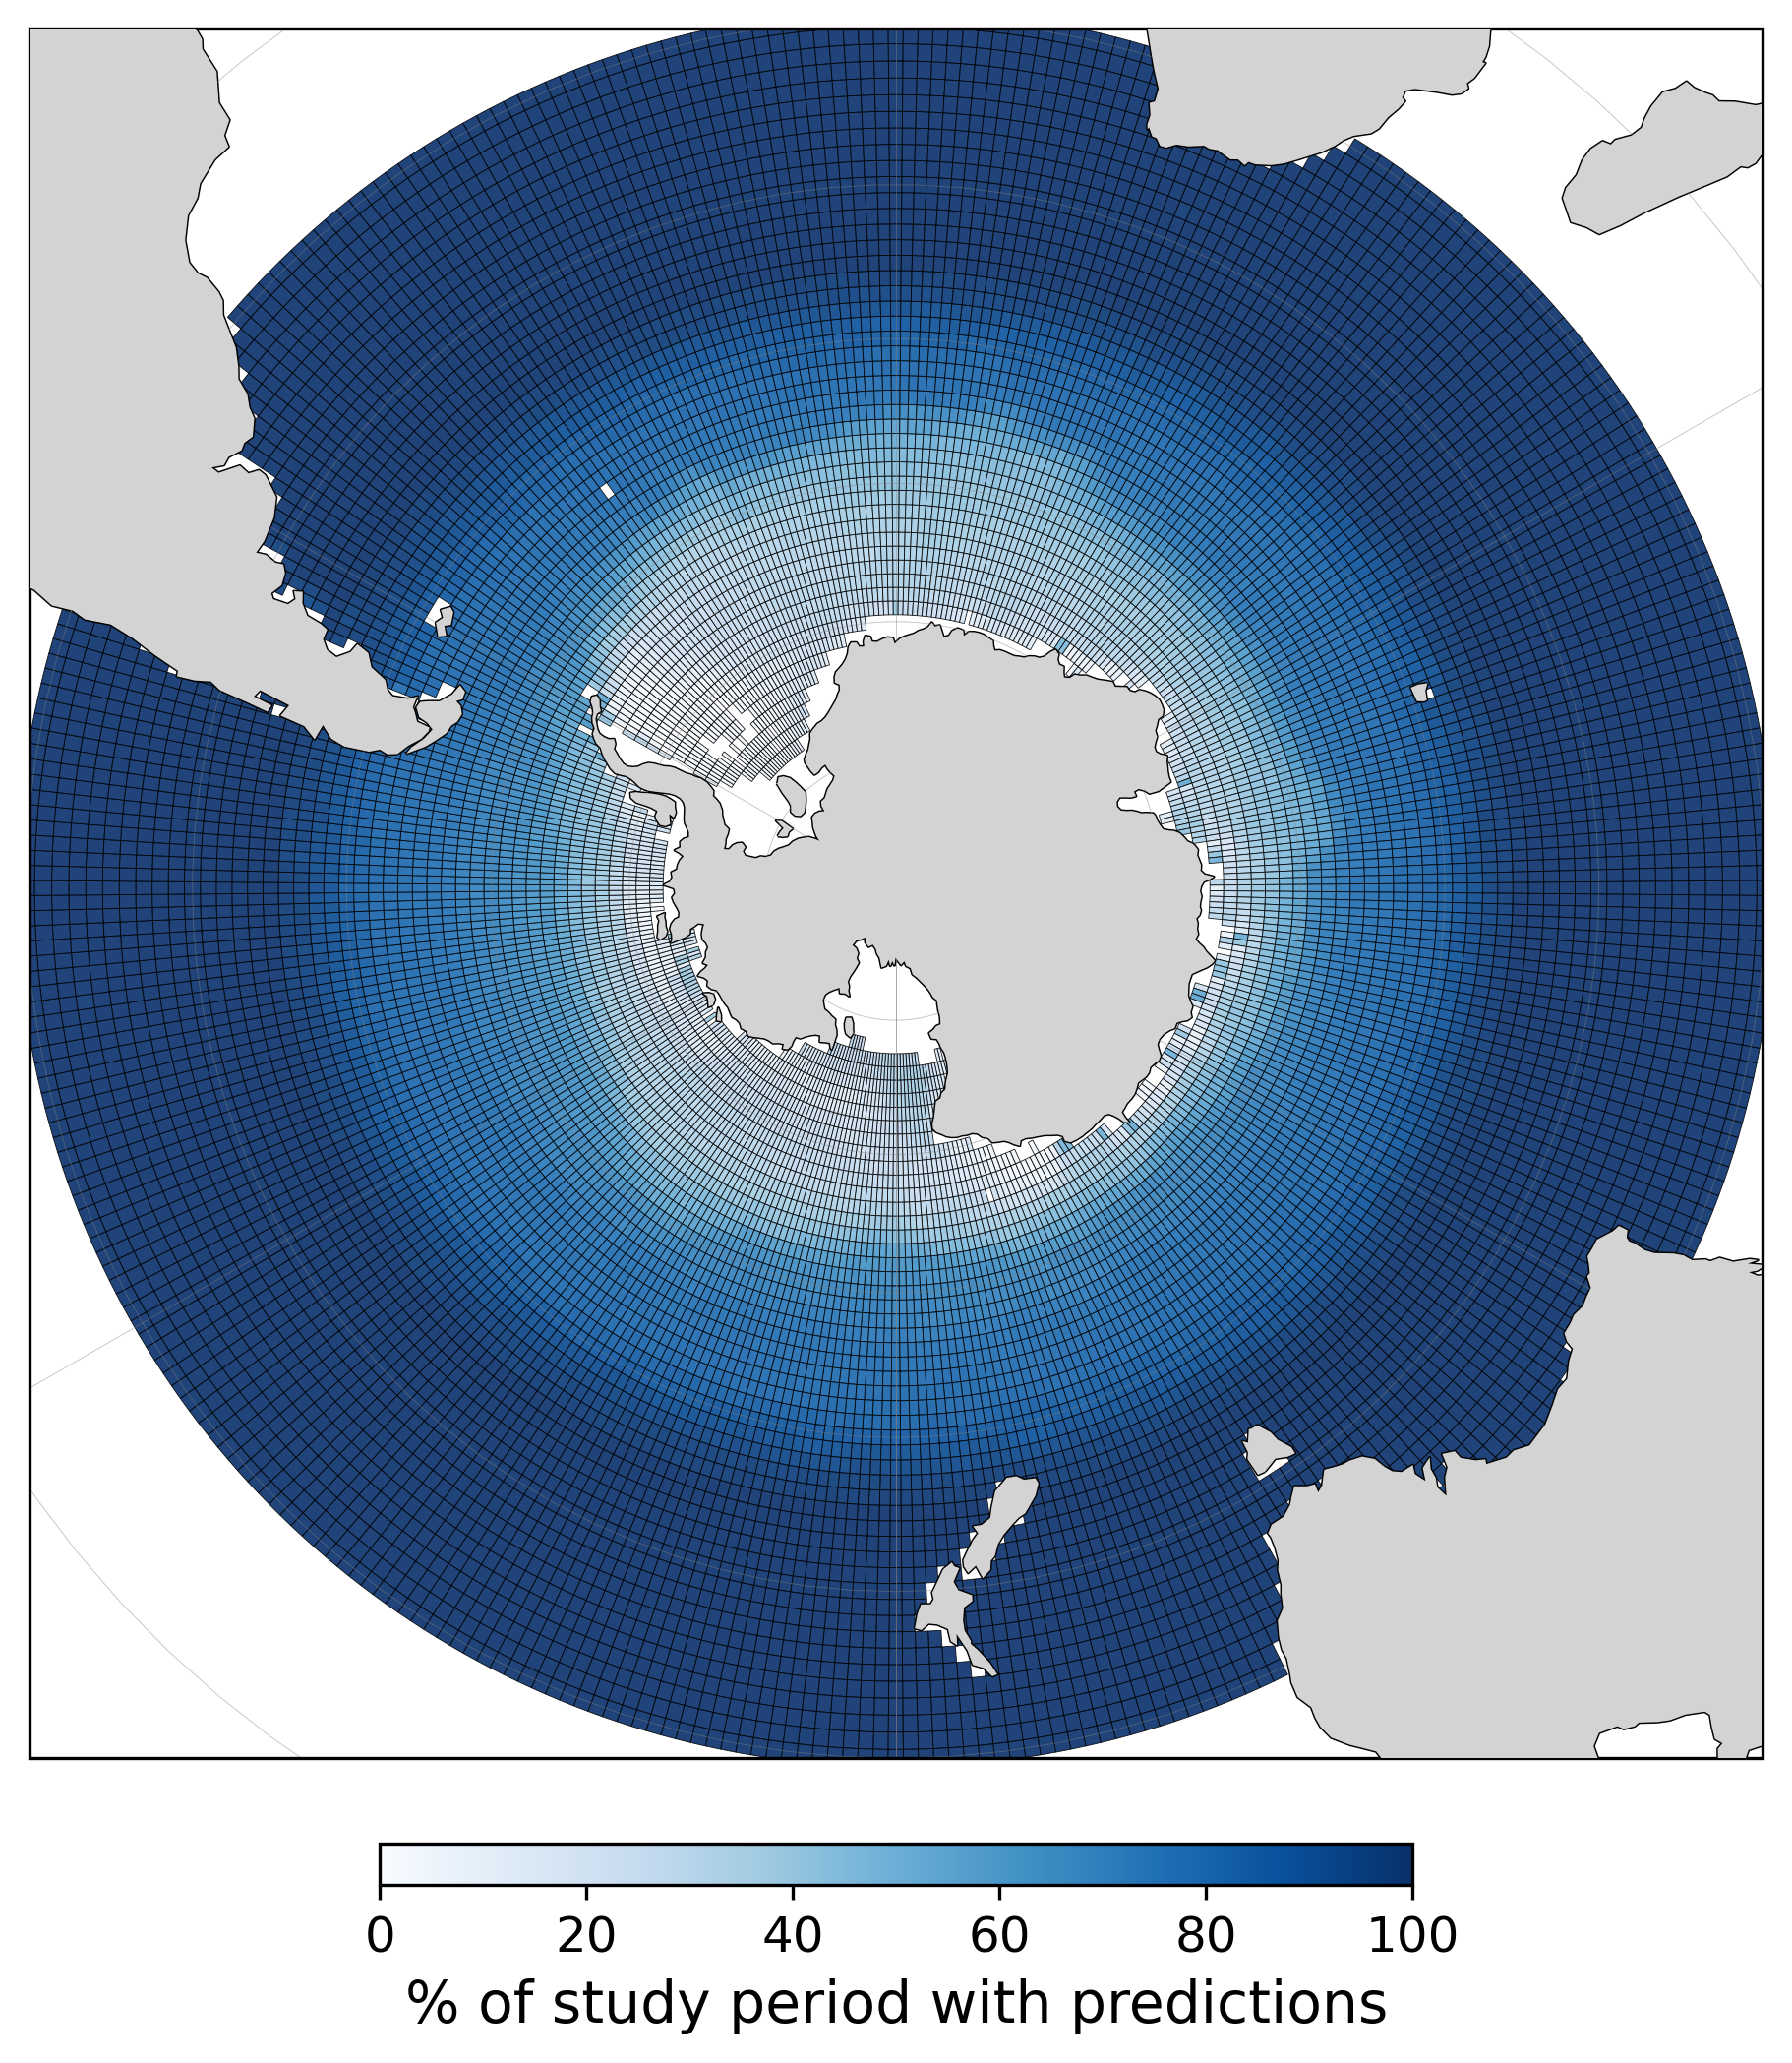

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ================================
# === LOAD MATRIX DATA ===========
# ================================
matrix = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/processing_steps/ARMOR3D_TSMLD_SouthernOcean_2003_2024_monthly_1deg_feature_engineered_monthly_1deg.csv",
    low_memory=False
)

# ================================
# === REBUILD TIME COLUMN ========
# ================================
matrix['time'] = pd.to_datetime(
    dict(year=matrix['year'], month=matrix['month'], day=15)
)

# ================================
# === FILTER TO SOUTHERN OCEAN ===
# ================================
start_date = "2003-01-01"
end_date   = "2024-12-31"

matrix = matrix[
    (matrix['lat_center'] <= -30) &
    (matrix['time'] >= start_date) &
    (matrix['time'] <= end_date)
].dropna()

# ================================
# === COVERAGE FUNCTION ==========
# ================================
def prepare_coverage(df, lat_col, lon_col, time_col):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()

    df['datetime'] = pd.to_datetime(df[time_col])
    df['month_center'] = df['datetime'].dt.to_period('M')

    unique_bins = df[[lat_col, lon_col, 'month_center']].drop_duplicates()

    grouped = (
        unique_bins
        .groupby([lat_col, lon_col])
        .size()
        .reset_index(name='month_count')
    )

    # 2003–2024 inclusive = 21 years = 252 months
    grouped['percent'] = 100 * grouped['month_count'] / 252

    return grouped

# ================================
# === COMPUTE MODEL COVERAGE =====
# ================================
matrix_coverage = prepare_coverage(
    matrix, 'lat_center', 'lon_center', 'time'
)

# ================================
# === PLOT COVERAGE MAP ==========
# ================================
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# --- Colormap ---
norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = plt.cm.Blues
sm = ScalarMappable(norm=norm, cmap=cmap)

# --- Draw grid cells ---
for _, row in matrix_coverage.iterrows():
    rect = Rectangle(
        (row['lon_center'], row['lat_center']), 1, 1,
        facecolor=cmap(norm(row['percent'])),
        edgecolor='k',
        linewidth=0.2,
        transform=ccrs.PlateCarree(),
        alpha=0.9
    )
    ax.add_patch(rect)

# --- Map features ---
ax.coastlines(resolution='110m', linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# ================================
# === COLORBAR ===================
# ================================
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label("% of study period with predictions", fontsize=14)
cb.ax.tick_params(labelsize=12)

# ================================
# === SAVE FIGURE ================
# ================================
plt.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/Fig3.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
